# GRUPPUPPGIFT - DEEP LEARNING - GRUPP5

## 1. Dataförståelse & preprocessing


### Importera bibliotek


In [ ]:
import random
import numpy as np
random.seed(42)
np.random.seed(42)

import tensorflow as tf
tf.random.set_seed(42)

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import os
os.makedirs("../images", exist_ok=True)

from sklearn.metrics import confusion_matrix, classification_report

from tensorflow import keras
from tensorflow.keras import layers

### Ladda in Fashion MNIST direkt från Keras

In [2]:
# Ladda datasetet från Keras
(x_train, y_train), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()

# Visa grundläggande information om datasetet
print("====Grundläggande information om datasetet====")
print(f"Träningsbilder: {x_train.shape} (bilder, höjd, bredd)")
print(f"Träningsetiketter: {y_train.shape}")
print(f"Testbilder: {x_test.shape}")
print(f"Testetiketter: {y_test.shape}")
print(f"Antal klasser: {len(np.unique(y_train))}")
print("Pixelvärdesintervall:", x_train.min(), "-", x_train.max())

====Grundläggande information om datasetet====
Träningsbilder: (60000, 28, 28) (bilder, höjd, bredd)
Träningsetiketter: (60000,)
Testbilder: (10000, 28, 28)
Testetiketter: (10000,)
Antal klasser: 10
Pixelvärdesintervall: 0 - 255


#### Undersök klasser och balans


==== Klassfördelning i träningssetet:====
0: T-shirt/top     - 6000 bilder
1: Trouser         - 6000 bilder
2: Pullover        - 6000 bilder
3: Dress           - 6000 bilder
4: Coat            - 6000 bilder
5: Sandal          - 6000 bilder
6: Shirt           - 6000 bilder
7: Sneaker         - 6000 bilder
8: Bag             - 6000 bilder
9: Ankle boot      - 6000 bilder


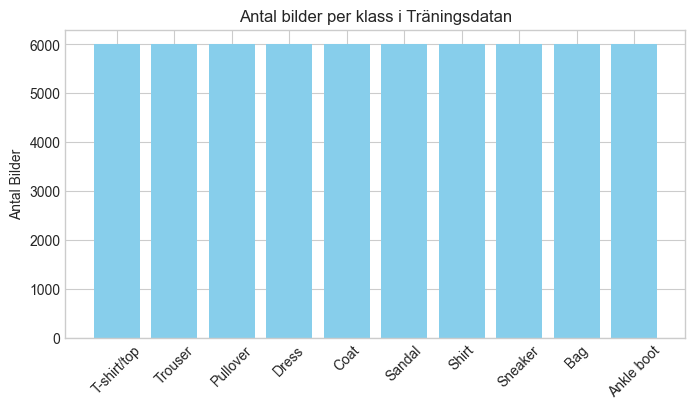

In [25]:
# Klassnamn ( enligt Fashion MNIST namnsättning)
class_names = [
    'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
    'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'
    ]

# Undersök klassbalans - räkna antal bilder per klass i träningssetet
unique, counts = np.unique(y_train, return_counts=True)

print("\n==== Klassfördelning i träningssetet:====")
for i, (name, cnt) in enumerate(zip(class_names, counts)):
    print(f"{i}: {name:15} - {cnt} bilder")

# Visualisera några exempelbilder från varje klass
plt.figure(figsize=(8, 4))
plt.bar(class_names, counts, color='skyblue')
plt.xticks(rotation=45)
plt.title("Antal bilder per klass i Träningsdatan")
plt.ylabel("Antal Bilder")
plt.savefig("../images/class_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

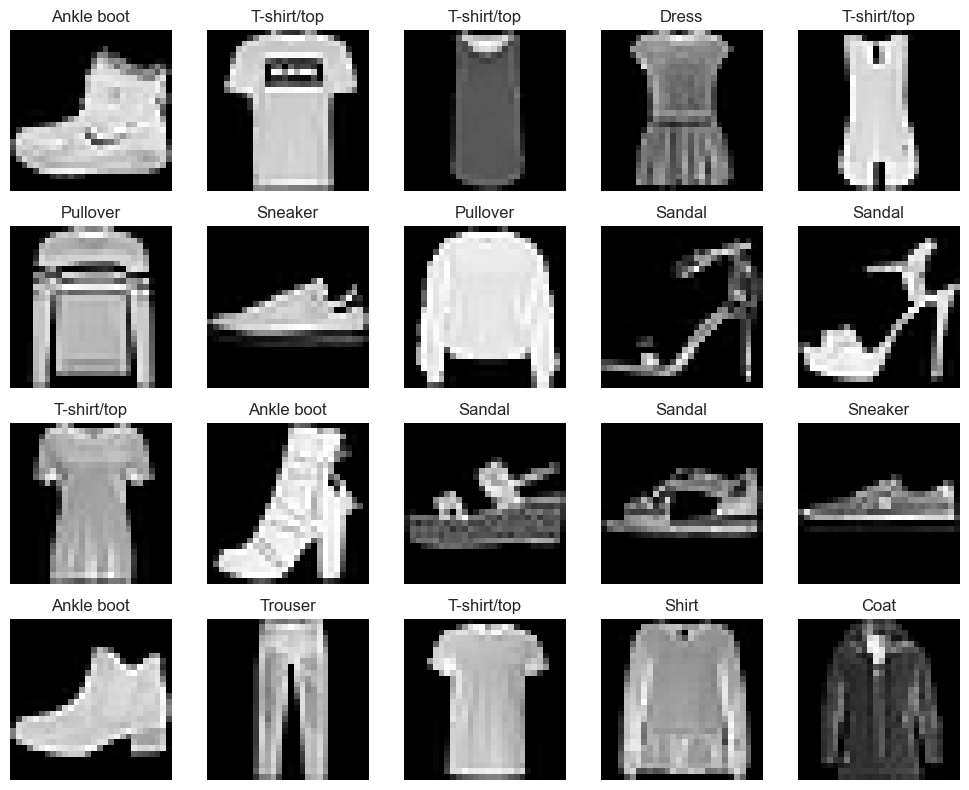

In [26]:
# Visa exempelbilder från träningsdatan
plt.figure(figsize=(10,8))
for i in range(20):
    plt.subplot(4,5,i+1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(class_names[y_train[i]])
    plt.axis('off')
plt.tight_layout()
plt.savefig("../images/example_images.png", dpi=150, bbox_inches="tight")
plt.show()

### Normalisera pixelvärdena till intervallet [0, 1]

In [5]:
# Normalisera pixelvärdena till intervallet [0,1]
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

print(f"\nEfter normalisering - pixelvärden mellan {x_train.min():.2f} och {x_train.max():.2f}")



Efter normalisering - pixelvärden mellan 0.00 och 1.00


### Anpassa input shape för CNN
CNN-lager i Keras kräver en kanaldimension - även för gråskalebilder.

In [6]:
# Lägg till en dimension för kanaler (gråskala) så att datan blir (28, 28, 1)
x_train = np.expand_dims(x_train, axis=-1)
x_test = np.expand_dims(x_test, axis=-1)

print(f"Ny shape för träningsdata: {x_train.shape} (bilder, höjd, bredd, kanaler)")
print(f"Ny shape för testdata: {x_test.shape}")

Ny shape för träningsdata: (60000, 28, 28, 1) (bilder, höjd, bredd, kanaler)
Ny shape för testdata: (10000, 28, 28, 1)


### Sammanfattning för del1:
Sammanfattning av data förståelse & preprocessing.
- Dataset: Fashion MNIST
- 60 000 träningsbilder, 10 000 testbilder
- Bildstorlek: 28x28 pixlar, gråskala
- Efter normalisering - pixelvärden mellan 0.00 och 1.00
- Input shape redo för CNN: (28, 28, 1)
- Inga saknade värden eller konstigheter
- Data är nu klar för att användas i modell

## 2. Baseline-modell & träning

Innan vi testar data augmentation behöver vi en referensmodell att jämföra mot.

Vi bygger en enkel CNN (Convolutional Neural Network) med följande struktur:
- 2 convolutional lager med ReLU-aktivering och max pooling
- 1 fully connected lager med 128 neuroner
- Output-lager med 10 neuroner (en per klass) och softmax-aktivering

Modellen tränas i 10 epoker utan någon augmentation. Resultatet blir vår **baseline** – utgångspunkten för alla jämförelser.

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8280 - loss: 0.4712 - val_accuracy: 0.8707 - val_loss: 0.3577
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8854 - loss: 0.3144 - val_accuracy: 0.8888 - val_loss: 0.3001
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9025 - loss: 0.2656 - val_accuracy: 0.8953 - val_loss: 0.2808
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9147 - loss: 0.2323 - val_accuracy: 0.9032 - val_loss: 0.2716
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9235 - loss: 0.2038 - val_accuracy: 0.9039 - val_loss: 0.2754
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9339 - loss: 0.1785 - val_accuracy: 0.9082 - val_loss: 0.2717
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9422 - loss: 0.1566 - val_accuracy: 0.9055 - val_loss: 0.2863
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9499 - loss: 0.1368 - 

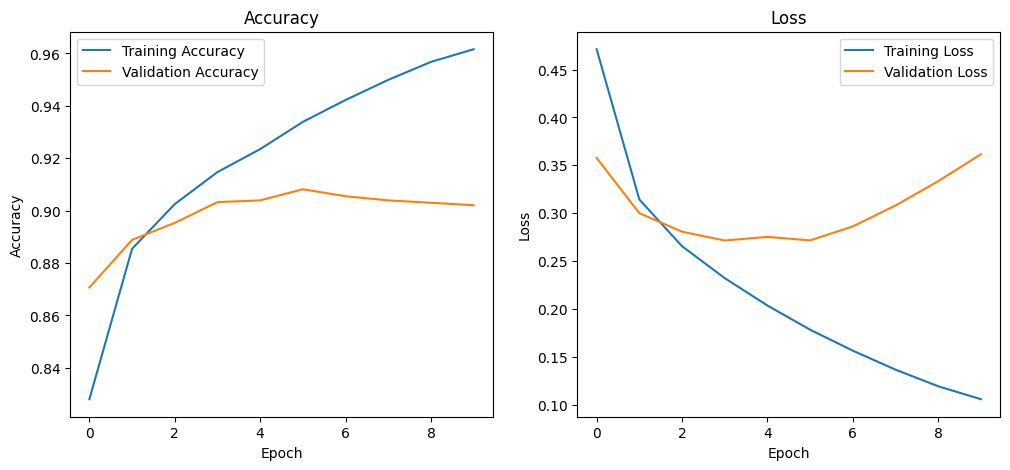

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8932 - loss: 0.3829
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8932 - loss: 0.3829
Test accuracy: 0.8932
Test loss: 0.3829


In [ ]:
# Baseline CNN-modell utan data augmentation

baseline_model = keras.Sequential([
    layers.Input(shape=(28, 28, 1)),
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

baseline_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_baseline = baseline_model.fit(
    x_train,
    y_train,
    epochs=10,
    validation_split=0.2,
    batch_size=32
)

# Visualisera accuracy och loss

plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history_baseline.history['accuracy'], label='Training Accuracy')
plt.plot(history_baseline.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(history_baseline.history['loss'], label='Training Loss')
plt.plot(history_baseline.history['val_loss'], label='Validation Loss')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.savefig("../images/baseline_training_curves.png", dpi=150, bbox_inches="tight")
plt.show()

# Utvärdera baseline-modellen på testdata

baseline_test_loss, baseline_test_accuracy = baseline_model.evaluate(x_test, y_test)
baseline_train_acc = history_baseline.history['accuracy'][-1]
baseline_val_acc = history_baseline.history['val_accuracy'][-1]
baseline_train_loss = history_baseline.history['loss'][-1]
baseline_val_loss = history_baseline.history['val_loss'][-1]

print(f"Test accuracy: {test_accuracy:.4f}")
print(f"Test loss: {test_loss:.4f}")

### Resultat: Baseline-modellen

Baseline-modellen uppnådde **test accuracy: 89.32%**.

**Vad vi ser i graferna:**

Accuracy-grafen visar att träningsnoggrannheten stiger stadigt genom alla 10 epoker och når ~96.2%, medan valideringsnoggrannheten planar ut redan efter epoch 4–5 och stannar runt 90%.

Loss-grafen är ännu tydligare: träningsförlusten fortsätter sjunka hela vägen ner till ~0.11, men valideringsförlusten når sitt minimum runt epoch 3–4 och börjar därefter stiga kontinuerligt upp till ~0.36 vid epoch 9.

Detta är ett tydligt tecken på **overfitting** — modellen fortsätter lära sig träningsdatan utantill, men försämras faktiskt på osedd data efter epoch 5. Det är just detta problem som data augmentation försöker motverka.

## 3. Fokusområde: Data Augmentation

I den här delen testar vi hur olika former av data augmentation påverkar modellen.

Data augmentation betyder att vi skapar små, realistiska variationer av träningsbilderna under träningen.  
Syftet är inte att skapa nya riktiga bilder, utan att hjälpa modellen att generalisera bättre och minska risken för overfitting.

Vi jämför varje experiment med baseline-modellen utan augmentation.

In [8]:
# Kontrollera att datan har rätt form innan augmentation
print("x_train shape:", x_train.shape)
print("x_test shape:", x_test.shape)

x_train shape: (60000, 28, 28, 1)
x_test shape: (10000, 28, 28, 1)


### Visa exempel på augmentation

Innan vi tränar modellerna visar vi hur en bild förändras av olika augmentation-lager.
Det gör det lättare att förstå vad modellen får se under träningen.

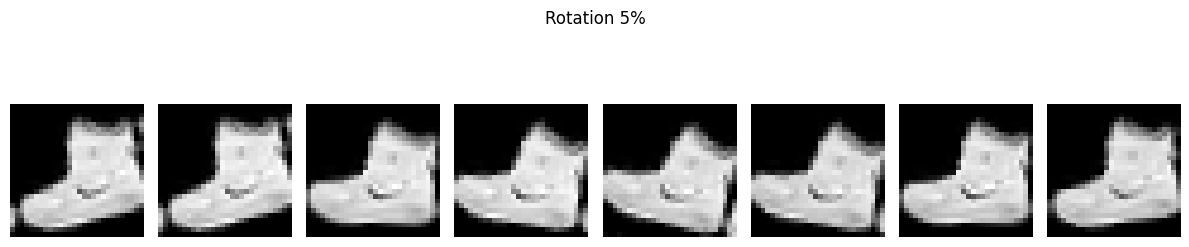

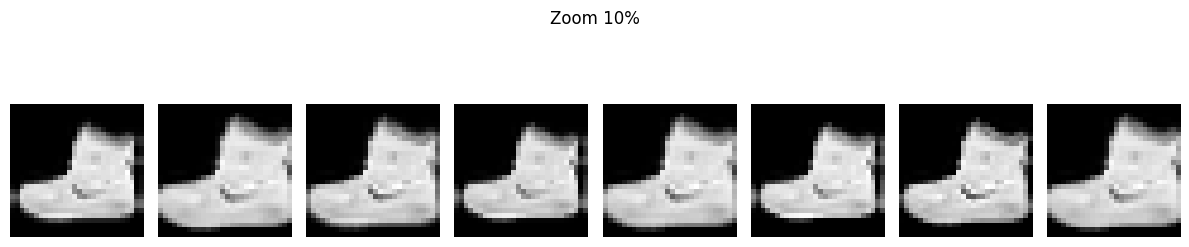

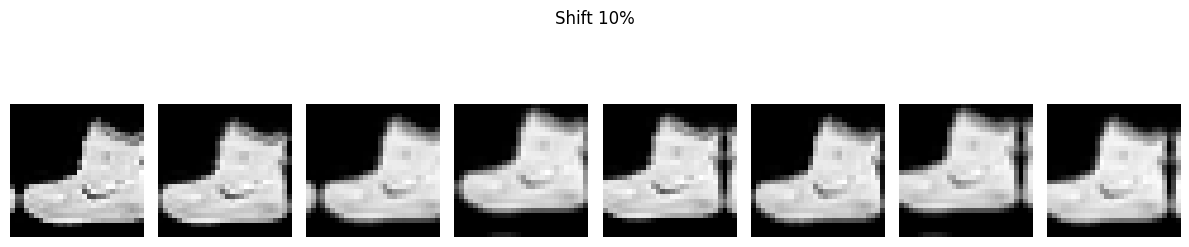

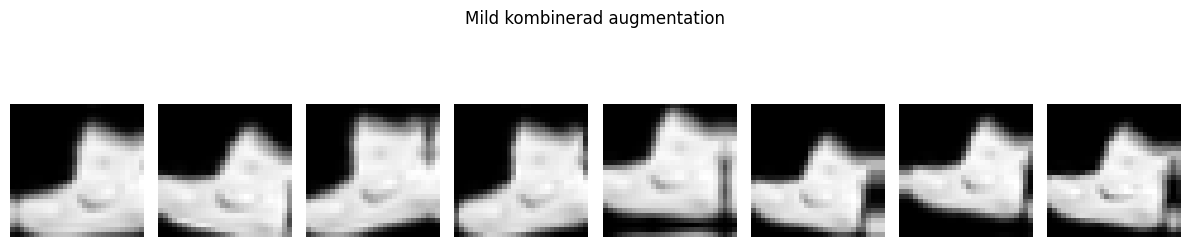

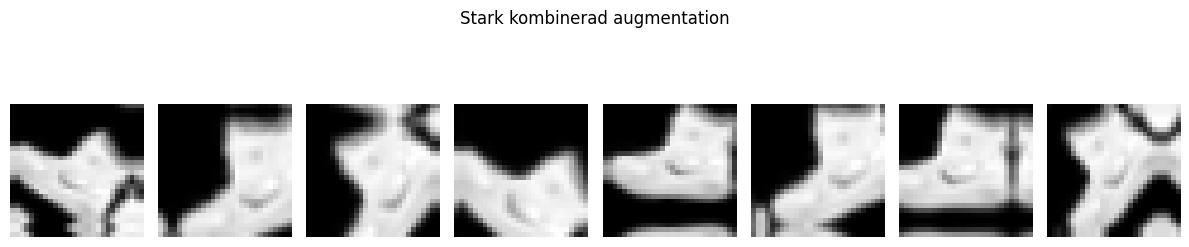

In [9]:
def show_augmented_examples(augmentation_layer, title, image_index=0, n_examples=8):
    image = x_train[image_index:image_index+1]

    plt.figure(figsize=(12, 3))
    for i in range(n_examples):
        augmented_image = augmentation_layer(image, training=True)
        plt.subplot(1, n_examples, i + 1)
        plt.imshow(augmented_image[0].numpy().squeeze(), cmap='gray')
        plt.axis('off')

    plt.suptitle(title)
    plt.tight_layout()
    plt.savefig(f"../images/augmentation_example_{title.lower().replace(' ', '_')}.png", 
                dpi=150, bbox_inches="tight")
    plt.show()


# Visa exempel för varje augmentation-typ separat
show_augmented_examples(
    keras.Sequential([layers.RandomRotation(0.05)]), 
    "Rotation 5%"
)
show_augmented_examples(
    keras.Sequential([layers.RandomZoom(0.10)]), 
    "Zoom 10%"
)
show_augmented_examples(
    keras.Sequential([layers.RandomTranslation(0.10, 0.10)]), 
    "Shift 10%"
)
show_augmented_examples(
    keras.Sequential([layers.RandomRotation(0.05), layers.RandomZoom(0.10), layers.RandomTranslation(0.10, 0.10)]),
    "Mild kombinerad augmentation"
)
show_augmented_examples(
    keras.Sequential([layers.RandomRotation(0.15), layers.RandomZoom(0.20), layers.RandomTranslation(0.20, 0.20)]),
    "Stark kombinerad augmentation"
)

### Funktion för att skapa samma CNN-modell

För att jämförelsen ska bli rättvis använder vi samma CNN-arkitektur i alla experiment.  
Det enda vi ändrar mellan experimenten är augmentation-delen.

In [10]:
def create_cnn_model(augmentation_layer=None):
    model = keras.Sequential()

    # Input-lager
    model.add(layers.Input(shape=(28, 28, 1)))

    # Augmentation används bara under träning.
    # Vid validation/test kör Keras automatiskt utan augmentation.
    if augmentation_layer is not None:
        model.add(augmentation_layer)

    # Samma CNN-struktur som baseline
    model.add(layers.Conv2D(32, (3, 3), activation='relu'))
    model.add(layers.MaxPooling2D((2, 2)))

    model.add(layers.Conv2D(64, (3, 3), activation='relu'))
    model.add(layers.MaxPooling2D((2, 2)))

    model.add(layers.Flatten())
    model.add(layers.Dense(128, activation='relu'))
    model.add(layers.Dense(10, activation='softmax'))

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

### Experimentfunktion

Den här funktionen tränar en modell, utvärderar den och sparar resultaten i en tabell.  
Det gör att vi inte tappar bort vad vi testade.

In [ ]:
experiment_results = []
experiment_histories = {}

def run_experiment(name, augmentation_layer=None, epochs=10, batch_size=32):
    print(f"\n===== Experiment: {name} =====")

    model = create_cnn_model(augmentation_layer)

    history_exp = model.fit(
        x_train,
        y_train,
        epochs=epochs,
        validation_split=0.2,
        batch_size=batch_size,
        verbose=1
    )

    test_loss, test_accuracy = model.evaluate(x_test, y_test, verbose=0)

    final_train_acc = history_exp.history['accuracy'][-1]
    final_val_acc = history_exp.history['val_accuracy'][-1]
    final_train_loss = history_exp.history['loss'][-1]
    final_val_loss = history_exp.history['val_loss'][-1]

    experiment_results.append({
        "experiment": name,
        "train_accuracy": final_train_acc,
        "val_accuracy": final_val_acc,
        "test_accuracy": test_accuracy,
        "train_loss": final_train_loss,
        "val_loss": final_val_loss,
        "test_loss": test_loss
    })

    experiment_histories[name] = history_exp

    print(f"Train accuracy: {final_train_acc:.4f}")
    print(f"Validation accuracy: {final_val_acc:.4f}")
    print(f"Test accuracy: {test_accuracy:.4f}")

    return model, history_exp

### Experiment 1: Endast rotation

Här testar vi om små rotationer hjälper modellen.  
För Fashion MNIST kan mild rotation vara rimligt, men för stark rotation kan vissa klädesplagg bli onaturliga.

In [12]:
rotation_aug = keras.Sequential([
    layers.RandomRotation(0.05)
])

rotation_model, rotation_history = run_experiment(
    name="Rotation 5%",
    augmentation_layer=rotation_aug
)


===== Experiment: Rotation 5% =====
Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.7958 - loss: 0.5548 - val_accuracy: 0.8500 - val_loss: 0.4117
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8598 - loss: 0.3864 - val_accuracy: 0.8674 - val_loss: 0.3642
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8767 - loss: 0.3360 - val_accuracy: 0.8834 - val_loss: 0.3263
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8857 - loss: 0.3089 - val_accuracy: 0.8912 - val_loss: 0.3078
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8929 - loss: 0.2877 - val_accuracy: 0.8972 - val_loss: 0.2932
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9005 - loss: 0.2695 - val_accuracy: 0.8973 - val_loss: 0.2912
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9038 - loss: 0.2545 - val_accuracy: 0.8986 - val_loss: 0.2908
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step

### Experiment 2: Endast zoom

Här testar vi om modellen blir bättre när plaggen ibland visas lite större eller mindre.  
Det kan hjälpa om objektet inte alltid är exakt centrerat eller lika stort.

In [13]:
zoom_aug = keras.Sequential([
    layers.RandomZoom(0.10)
])

zoom_model, zoom_history = run_experiment(
    name="Zoom 10%",
    augmentation_layer=zoom_aug
)


===== Experiment: Zoom 10% =====
Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8078 - loss: 0.5230 - val_accuracy: 0.8712 - val_loss: 0.3598
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8707 - loss: 0.3526 - val_accuracy: 0.8872 - val_loss: 0.3156
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8882 - loss: 0.3022 - val_accuracy: 0.8947 - val_loss: 0.2912
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8999 - loss: 0.2718 - val_accuracy: 0.8967 - val_loss: 0.2851
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9080 - loss: 0.2459 - val_accuracy: 0.8995 - val_loss: 0.2780
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9179 - loss: 0.2248 - val_accuracy: 0.9035 - val_loss: 0.2747
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9218 - loss: 0.2089 - val_accuracy: 0.9023 - val_loss: 0.2868
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - 

### Experiment 3: Endast translation/shift

Här flyttas bilden lite i höjd- och sidled.  
Det kan hjälpa modellen att inte bli för beroende av exakt position i bilden.

In [14]:
shift_aug = keras.Sequential([
    layers.RandomTranslation(0.10, 0.10)
])

shift_model, shift_history = run_experiment(
    name="Shift 10%",
    augmentation_layer=shift_aug
)


===== Experiment: Shift 10% =====
Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.7619 - loss: 0.6300 - val_accuracy: 0.8425 - val_loss: 0.4362
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8338 - loss: 0.4439 - val_accuracy: 0.8618 - val_loss: 0.3761
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8548 - loss: 0.3884 - val_accuracy: 0.8785 - val_loss: 0.3371
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8672 - loss: 0.3562 - val_accuracy: 0.8843 - val_loss: 0.3237
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8745 - loss: 0.3345 - val_accuracy: 0.8851 - val_loss: 0.3140
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8812 - loss: 0.3148 - val_accuracy: 0.8958 - val_loss: 0.2879
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8861 - loss: 0.3026 - val_accuracy: 0.8938 - val_loss: 0.2917
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step -

### Experiment 4: Mild kombinerad augmentation

Här kombinerar vi rotation, zoom och shift i mild nivå.  
Detta är ofta mer realistiskt än att bara testa en sak, men för mycket augmentation kan också störa modellen.

In [15]:
mild_combined_aug = keras.Sequential([
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.10),
    layers.RandomTranslation(0.10, 0.10)
])

mild_combined_model, mild_combined_history = run_experiment(
    name="Mild kombinerad augmentation",
    augmentation_layer=mild_combined_aug
)


===== Experiment: Mild kombinerad augmentation =====
Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.7371 - loss: 0.7004 - val_accuracy: 0.7946 - val_loss: 0.5708
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.8059 - loss: 0.5164 - val_accuracy: 0.8375 - val_loss: 0.4440
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.8268 - loss: 0.4585 - val_accuracy: 0.8430 - val_loss: 0.4234
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.8399 - loss: 0.4243 - val_accuracy: 0.8397 - val_loss: 0.4214
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.8490 - loss: 0.4014 - val_accuracy: 0.8507 - val_loss: 0.3997
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.8546 - loss: 0.3879 - val_accuracy: 0.8418 - val_loss: 0.4223
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.8605 - loss: 0.3715 - val_accuracy: 0.8550 - val_loss: 0.3849
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━

### Experiment 5: Starkare kombinerad augmentation

Här testar vi en starkare variant för att se om mer augmentation hjälper eller skadar.  
På små 28x28-bilder kan stark augmentation ibland göra viktig information svårare att tolka.

In [16]:
strong_combined_aug = keras.Sequential([
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.20),
    layers.RandomTranslation(0.20, 0.20)
])

strong_combined_model, strong_combined_history = run_experiment(
    name="Stark kombinerad augmentation",
    augmentation_layer=strong_combined_aug
)


===== Experiment: Stark kombinerad augmentation =====
Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.5715 - loss: 1.1764 - val_accuracy: 0.6988 - val_loss: 0.7996
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.6859 - loss: 0.8569 - val_accuracy: 0.7287 - val_loss: 0.7174
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.7142 - loss: 0.7753 - val_accuracy: 0.6927 - val_loss: 0.8357
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.7362 - loss: 0.7202 - val_accuracy: 0.7703 - val_loss: 0.6089
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.7498 - loss: 0.6815 - val_accuracy: 0.7740 - val_loss: 0.6236
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.7620 - loss: 0.6497 - val_accuracy: 0.7822 - val_loss: 0.5880
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.7684 - loss: 0.6320 - val_accuracy: 0.7728 - val_loss: 0.5980
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━

### Jämförelsetabell – alla experiment

Tabellen nedan sammanfattar resultaten från baseline och alla fem augmentation-experiment,
sorterade efter test accuracy.

In [17]:
# Lägg till baseline manuellt
baseline_row = {
    "experiment": "Baseline (ingen augmentation)",
    "train_accuracy": baseline_train_acc,
    "val_accuracy": baseline_val_acc,
    "test_accuracy": baseline_test_accuracy,
    "train_loss": baseline_train_loss,
    "val_loss": baseline_val_loss,
    "test_loss": baseline_test_loss,
    "comment": "Referensmodell utan augmentation"
}

results_df = pd.DataFrame([baseline_row] + experiment_results)

# Beräkna overfitting-gap
results_df["overfitting_gap"] = results_df["train_accuracy"] - results_df["val_accuracy"]

# Sortera efter test accuracy
results_df = results_df.sort_values("test_accuracy", ascending=False).reset_index(drop=True)

# Runda av
display_cols = ["experiment", "train_accuracy", "val_accuracy", "test_accuracy", "overfitting_gap"]
display(results_df[display_cols].round(4))

,experiment,train_accuracy,val_accuracy,test_accuracy,overfitting_gap
0,Shift 10%,0.8964,0.9027,0.9035,-0.0063
1,Zoom 10%,0.9370,0.8997,0.8982,0.0373
2,Rotation 5%,0.9166,0.9045,0.8942,0.0121
3,Baseline (ingen augmentation),0.9616,0.9021,0.8932,0.0595
4,Mild kombinerad augmentation,0.8692,0.8759,0.8722,-0.0067
5,Stark kombinerad augmentation,0.7855,0.7821,0.7837,0.0034


**Vad tabellen visar:**

**Test accuracy** är det viktigaste måttet — det mäter hur modellen presterar på helt osedd data.
Shift 10% presterar bäst (90.35%), tätt följt av Zoom 10% (89.82%) och Rotation 5% (89.42%).
Baseline (89.32%) ligger strax under de tre bästa augmentation-experimenten.

**Overfitting gap** (train accuracy − val accuracy) visar hur mycket modellen överanpassar sig.
Baseline har det klart högsta gapet (0.0595) — den lär sig träningsdatan mycket bättre än
den generaliserar. Shift och Mild kombinerad har negativt gap, vilket betyder att
val accuracy faktiskt är högre än train accuracy. Det händer när augmentation gör
träningen svårare än validering, eftersom augmentation bara tillämpas under träning.

**Stark kombinerad augmentation** presterar sämst på alla mått — bilderna förändras
för mycket och modellen har svårt att lära sig meningsfulla mönster.

## 4. Visualisering, analys & slutsatser

I den här delen analyserar vi resultaten från alla experiment genom visualiseringar.
Vi tittar på träningskurvor, jämför test accuracy, analyserar overfitting och
undersöker vilka klasser som är svårast att klassificera.

In [18]:
# Konsekvent färgschema för alla grafer
COLORS = {
    "Baseline (ingen augmentation)": "black",
    "Rotation 5%":                   "steelblue",
    "Zoom 10%":                      "darkorange",
    "Shift 10%":                     "seagreen",
    "Mild kombinerad augmentation":  "purple",
    "Stark kombinerad augmentation": "red"
}

plt.style.use("seaborn-v0_8-whitegrid")

### Kombinerade valideringskurvor

Grafen nedan visar validation accuracy och validation loss för alla experiment
under träningen, med baseline som referens (svart streckad linje).

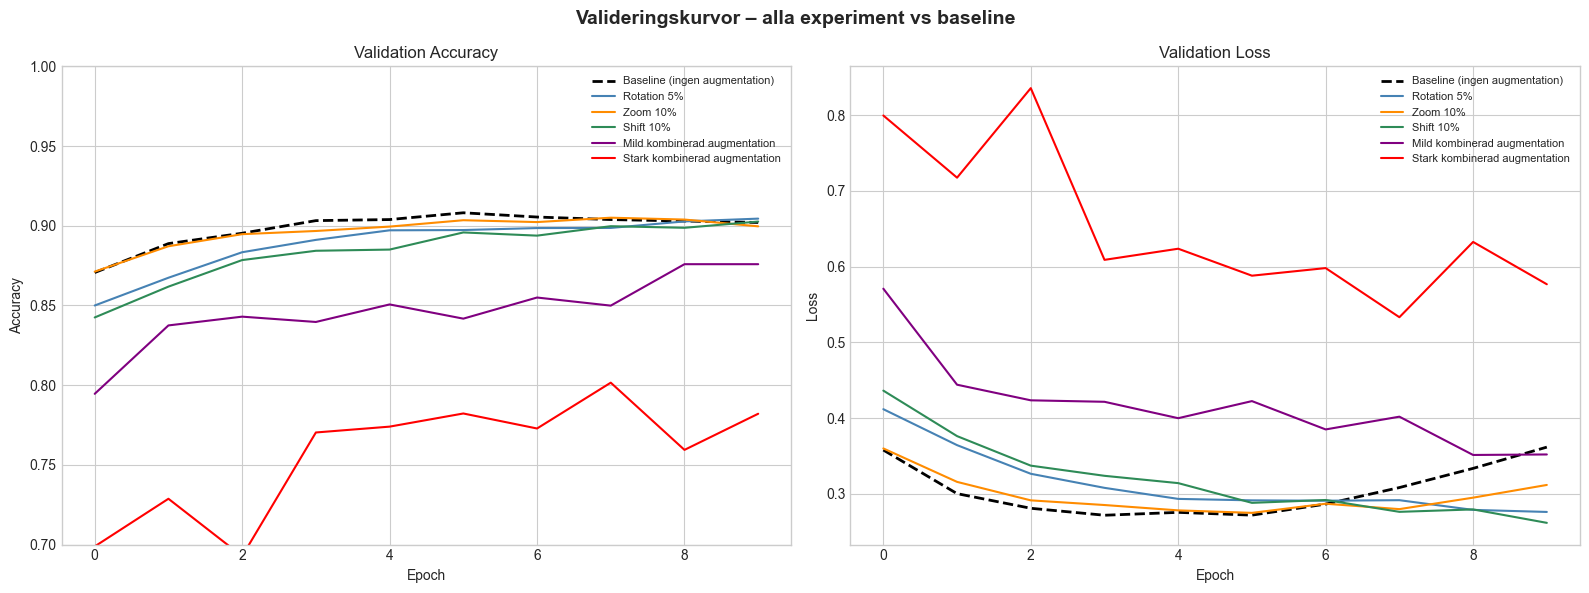

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Valideringskurvor – alla experiment vs baseline", fontsize=14, fontweight="bold")

for name, color in COLORS.items():
    if name == "Baseline (ingen augmentation)":
        axes[0].plot(history_baseline.history["val_accuracy"],
                     label=name, color=color, linestyle="--", linewidth=2)
        axes[1].plot(history_baseline.history["val_loss"],
                     label=name, color=color, linestyle="--", linewidth=2)
    else:
        axes[0].plot(experiment_histories[name].history["val_accuracy"],
                     label=name, color=color)
        axes[1].plot(experiment_histories[name].history["val_loss"],
                     label=name, color=color)

axes[0].set_title("Validation Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].set_ylim(0.70, 1.0)
axes[0].legend(fontsize=8)

axes[1].set_title("Validation Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig("../images/combined_validation_curves.png", dpi=150, bbox_inches="tight")
plt.show()

**Vad vi ser:**

I accuracy-grafen ligger baseline, Rotation 5%, Zoom 10% och Shift 10% nära
varandra och når ~90% vid epoch 9. Mild kombinerad augmentation presterar
något sämre (~87–88%) och Stark kombinerad tydligt sämre (~78%).

Loss-grafen berättar en viktigare historia: baseline-modellens valideringsförlust
börjar stiga efter epoch 6 och når ~0.36 vid epoch 9 — ett tydligt tecken på
overfitting. Shift 10% och Rotation 5% fortsätter däremot att minska eller
stabiliseras, vilket tyder på bättre generalisering trots liknande accuracy.

Stark kombinerad augmentation visar hög och instabil valideringsförlust genom
hela träningen — bilderna förändras för mycket för att modellen ska kunna
lära sig meningsfulla mönster.

### Individuella träningskurvor per experiment

Nedan visas tränings- och valideringskurvor för varje experiment separat.
Det gör det lättare att se hur varje augmentation-typ påverkar inlärningen.

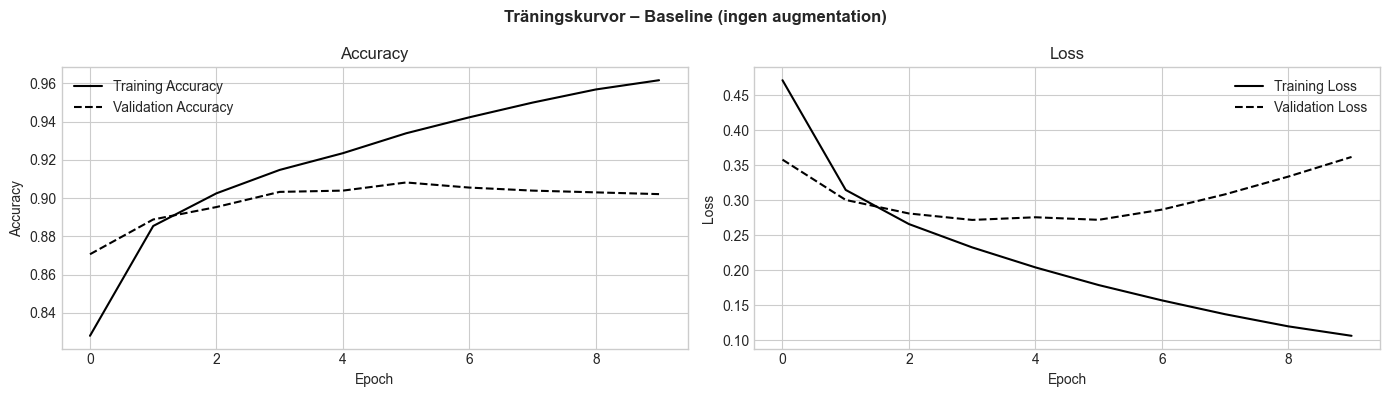

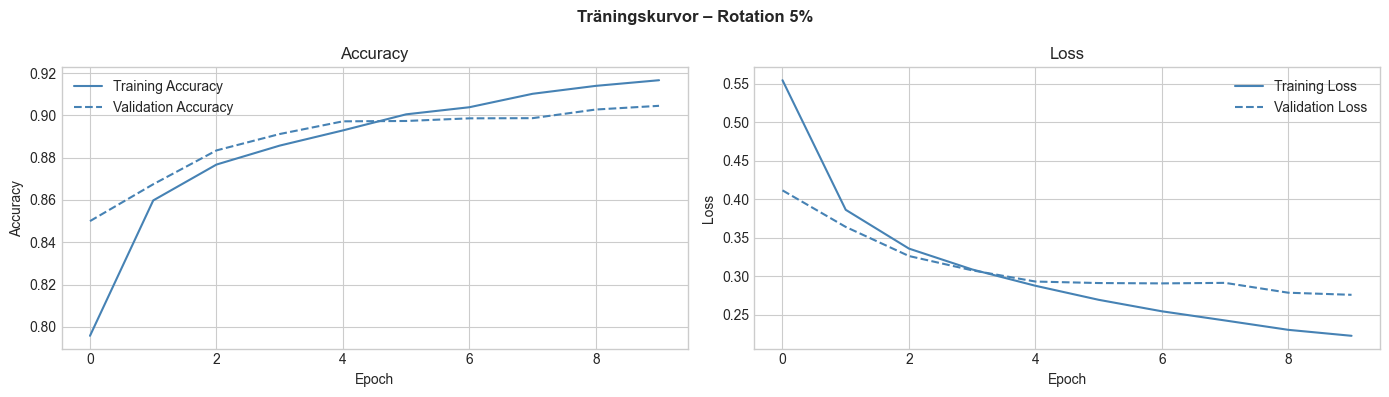

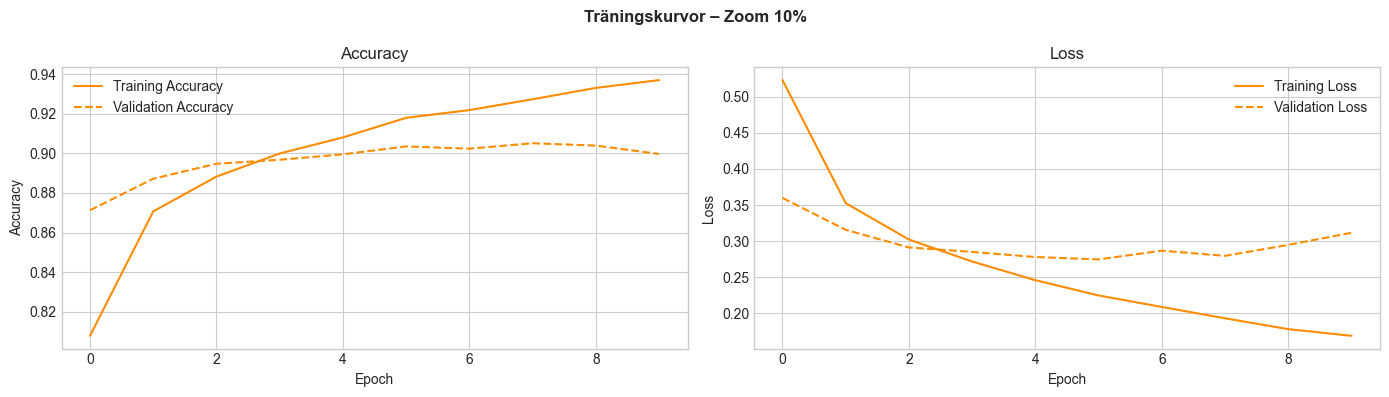

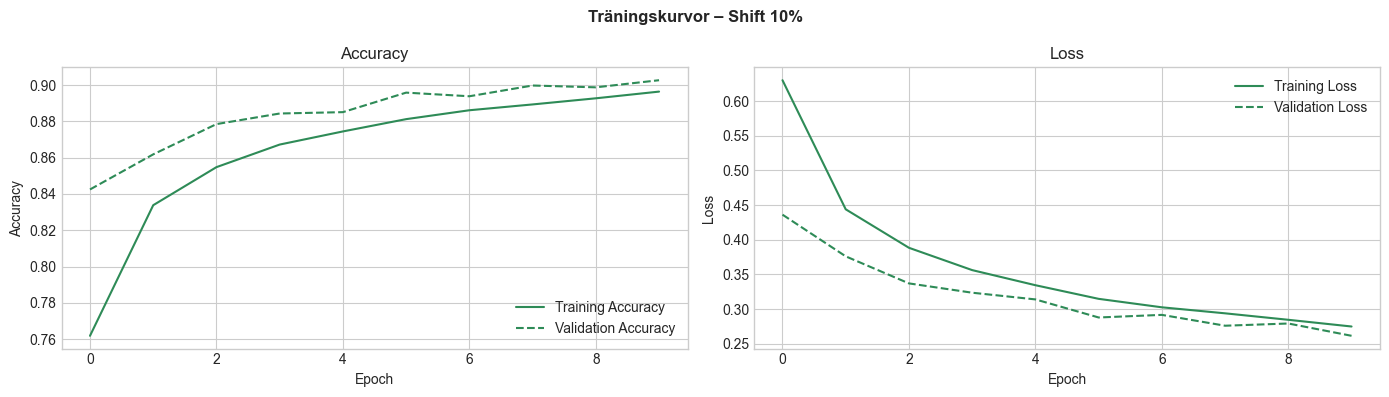

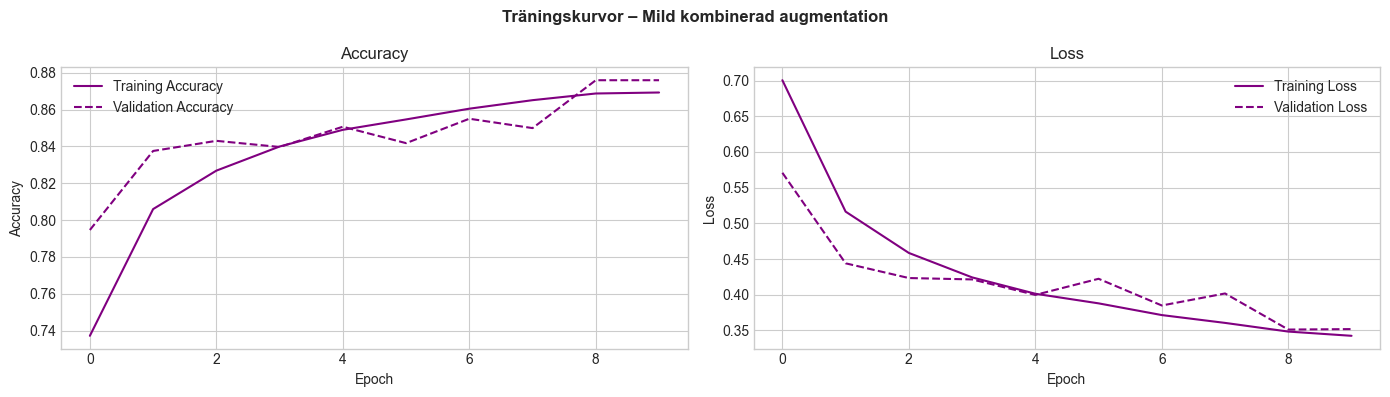

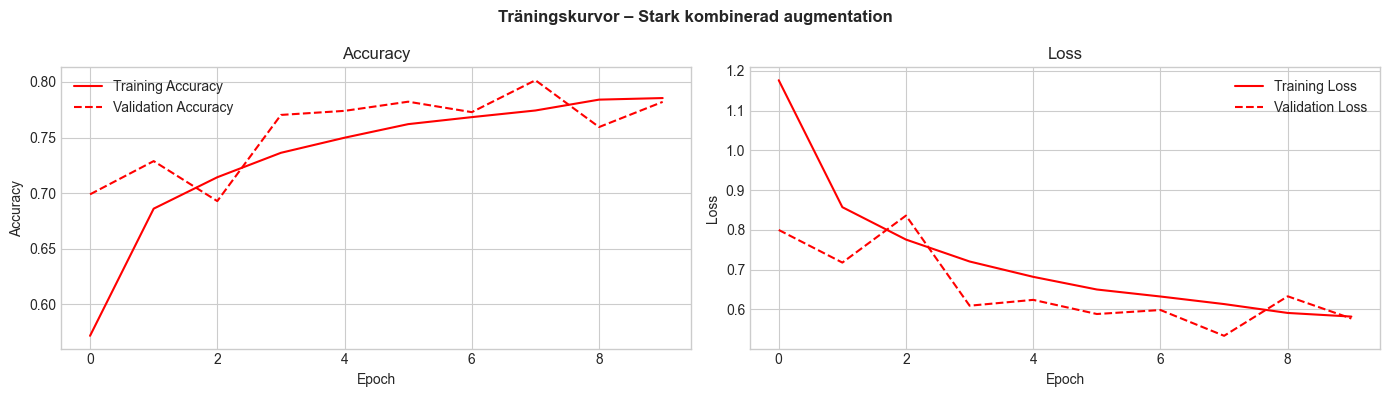

In [ ]:
for name, color in COLORS.items():
    if name == "Baseline (ingen augmentation)":
        hist = history_baseline
    else:
        hist = experiment_histories[name]

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    fig.suptitle(f"Träningskurvor – {name}", fontsize=12, fontweight="bold")

    axes[0].plot(hist.history["accuracy"], label="Training Accuracy", color=color)
    axes[0].plot(hist.history["val_accuracy"], label="Validation Accuracy",
                 color=color, linestyle="--")
    axes[0].set_title("Accuracy")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Accuracy")
    axes[0].legend()

    axes[1].plot(hist.history["loss"], label="Training Loss", color=color)
    axes[1].plot(hist.history["val_loss"], label="Validation Loss",
                 color=color, linestyle="--")
    axes[1].set_title("Loss")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Loss")
    axes[1].legend()

    plt.tight_layout()
    filename = name.lower().replace(" ", "_").replace("%", "pct").replace("/", "")
    plt.savefig(f"../images/training_curves_{filename}.png", dpi=150, bbox_inches="tight")
    plt.show()

**Baseline (ingen augmentation)**
Träningsnoggrannheten stiger stadigt till ~96% medan valideringen planar ut runt 90%.
Loss-grafen visar tydlig overfitting — träningsförlusten fortsätter sjunka till ~0.11
men valideringsförlusten vänder uppåt efter epoch 4 och når ~0.36 vid epoch 9.
Det växande gapet är ett klassiskt tecken på att modellen memorerar träningsdatan.

---

**Rotation 5%**
Kurvorna ligger nära varandra genom hela träningen — gapet mellan träning och
validering är litet (0.012). Valideringsförlusten fortsätter sjunka svagt och
stabiliseras runt 0.28, utan den uppåtgående trend vi såg i baseline.
Rotation verkar hjälpa modellen att generalisera något bättre.

---

**Zoom 10%**
Träningsnoggrannheten stiger till ~94% medan valideringen planar ut runt 90%.
Gapet är märkbart (0.037) — näst störst efter baseline. Valideringsförlusten
stabiliseras runt 0.28–0.31 men börjar ticka uppåt mot slutet, vilket antyder
att zoom skapar viss overfitting trots augmentation.

---

**Shift 10%**
Det mest intressanta mönstret: valideringsnoggrannheten ligger *över* träningsnoggrannheten
under de första epocherna, och gapet är negativt (-0.006). Valideringsförlusten
sjunker konsekvent och når ~0.27 vid epoch 9 utan att vända uppåt.
Shift verkar vara den augmentation som bäst motverkar overfitting på detta dataset.

---

**Mild kombinerad augmentation**
Kurvorna följs åt men fluktuerar mer än de enklare experimenten, vilket tyder på
att kombinationen av tre transformationer gör träningen mer instabil.
Accuracy når ~87–88% — lägre än de enskilda augmentation-experimenten.
Modellen verkar ha svårare att lära sig när bilderna förändras på flera sätt samtidigt.

---

**Stark kombinerad augmentation**
Klart sämst resultat. Accuracy når bara ~78% och kurvorna är instabila och
fluktuerar kraftigt, särskilt i loss-grafen. Valideringsförlusten oscillerar
mellan 0.60–0.83 utan tydlig förbättring efter epoch 3.
Augmentationen är för aggressiv — bilderna förändras så mycket att modellen
inte kan lära sig de visuella mönster som skiljer klasserna åt.

### Test Accuracy per experiment

Stapeldiagrammet visar test accuracy för alla experiment, sorterat från bäst till sämst.
Den streckade linjen markerar baseline (0.8932) som referens.

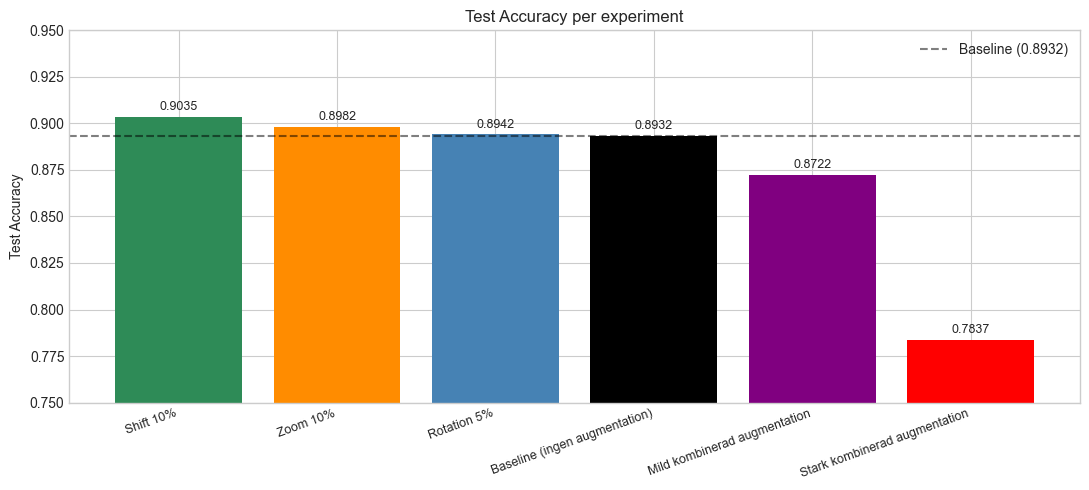

In [ ]:
fig, ax = plt.subplots(figsize=(11, 5))

bar_colors = [COLORS[exp] for exp in results_df["experiment"]]
bars = ax.bar(results_df["experiment"], results_df["test_accuracy"], color=bar_colors)

for bar in bars:
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.002,
            f"{bar.get_height():.4f}",
            ha="center", va="bottom", fontsize=9)

ax.set_ylim(0.75, 0.95)
ax.set_ylabel("Test Accuracy")
ax.set_title("Test Accuracy per experiment")
ax.axhline(y=baseline_test_accuracy, color="black", linestyle="--",
           alpha=0.5, label=f"Baseline ({baseline_test_accuracy:.4f})")
ax.legend()
plt.xticks(rotation=20, ha="right", fontsize=9)
plt.tight_layout()
plt.savefig("../images/test_accuracy_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

Shift 10% presterar bäst med 90.35%, tätt följt av Zoom 10% (89.82%) och
Rotation 5% (89.42%). Alla tre ligger över baseline, men skillnaderna är små —
mellan 0.1 och 1.0 procentenheter.

Mild kombinerad augmentation (87.22%) och Stark kombinerad augmentation (78.37%)
presterar sämre än baseline. Att kombinera flera transformationer samtidigt
hjälper alltså inte — det skadar modellen när styrkan är för hög.

Notera att de fyra översta experimenten ligger väldigt nära varandra (inom ~1%).
Test accuracy ensamt räcker därför inte för att avgöra vilket experiment som är
bäst — vi behöver också titta på overfitting-gapet och träningskurvorna.

### Overfitting-gap per experiment

Overfitting-gapet mäter skillnaden mellan träningsnoggrannhet och valideringsnoggrannhet
(train accuracy − val accuracy). Ett högt positivt värde betyder att modellen presterar
mycket bättre på träningsdata än på osedd data — ett tecken på overfitting.
Negativt värde betyder att val accuracy faktiskt är högre än train accuracy.

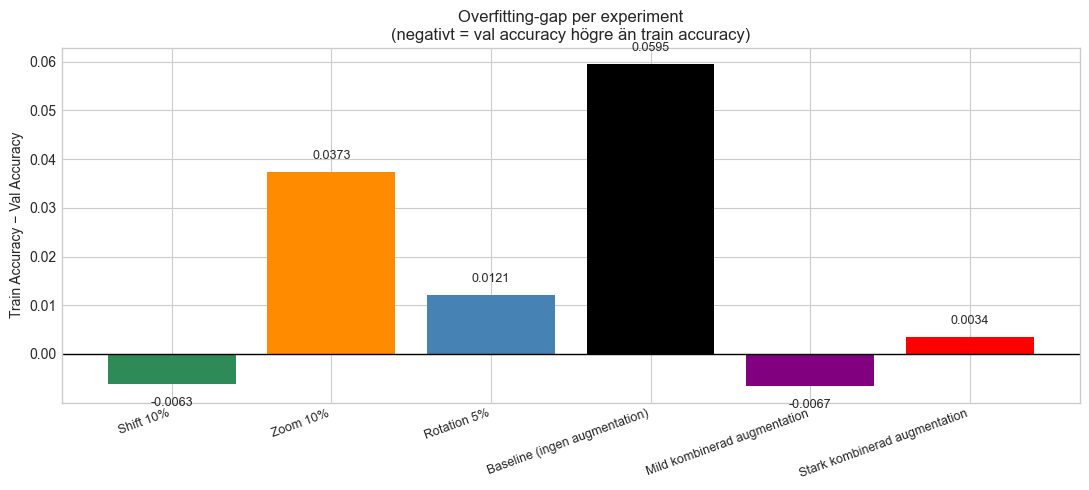

In [ ]:
fig, ax = plt.subplots(figsize=(11, 5))

gap_colors = [COLORS[exp] for exp in results_df["experiment"]]
bars = ax.bar(results_df["experiment"], results_df["overfitting_gap"], color=gap_colors)

for bar in bars:
    ypos = bar.get_height() + 0.002 if bar.get_height() >= 0 else bar.get_height() - 0.005
    ax.text(bar.get_x() + bar.get_width() / 2,
            ypos,
            f"{bar.get_height():.4f}",
            ha="center", va="bottom", fontsize=9)

ax.axhline(y=0, color="black", linewidth=1)
ax.set_ylabel("Train Accuracy − Val Accuracy")
ax.set_title("Overfitting-gap per experiment\n(negativt = val accuracy högre än train accuracy)")
plt.xticks(rotation=20, ha="right", fontsize=9)
plt.tight_layout()
plt.savefig("../images/overfitting_gap.png", dpi=150, bbox_inches="tight")
plt.show()

**Baseline** har det klart högsta gapet (0.0595) — modellen lär sig träningsdatan
betydligt bättre än den generaliserar, vilket bekräftar overfitting vi såg i träningskurvorna.

**Zoom 10%** har det näst högsta gapet (0.0373) trots relativt god test accuracy.
Det tyder på att zoom-augmentation inte löser overfitting-problemet helt.

**Rotation 5%** har ett litet positivt gap (0.0121) — träning och validering
ligger nära varandra, vilket är ett gott tecken.

**Shift 10%** och **Mild kombinerad augmentation** har negativa gap (-0.0063 och -0.0067).
Det betyder att val accuracy är högre än train accuracy. Detta är förväntat när
augmentation används — transformationerna gör träningen svårare eftersom bilderna
ständigt förändras, medan valideringen alltid sker på orörda originalbilder.
Det är alltså inte ett problem, utan ett tecken på att augmentation fungerar som avsett.

**Stark kombinerad augmentation** har ett nära nollvärde (0.0034) men av fel anledning —
både träning och validering presterar dåligt, så gapet är litet men accuracy är låg.

### Confusion Matrix – Baseline

Confusion matrix visar hur modellen klassificerar varje klass — diagonalen är
korrekta förutsägelser, och allt utanför diagonalen är fel.

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


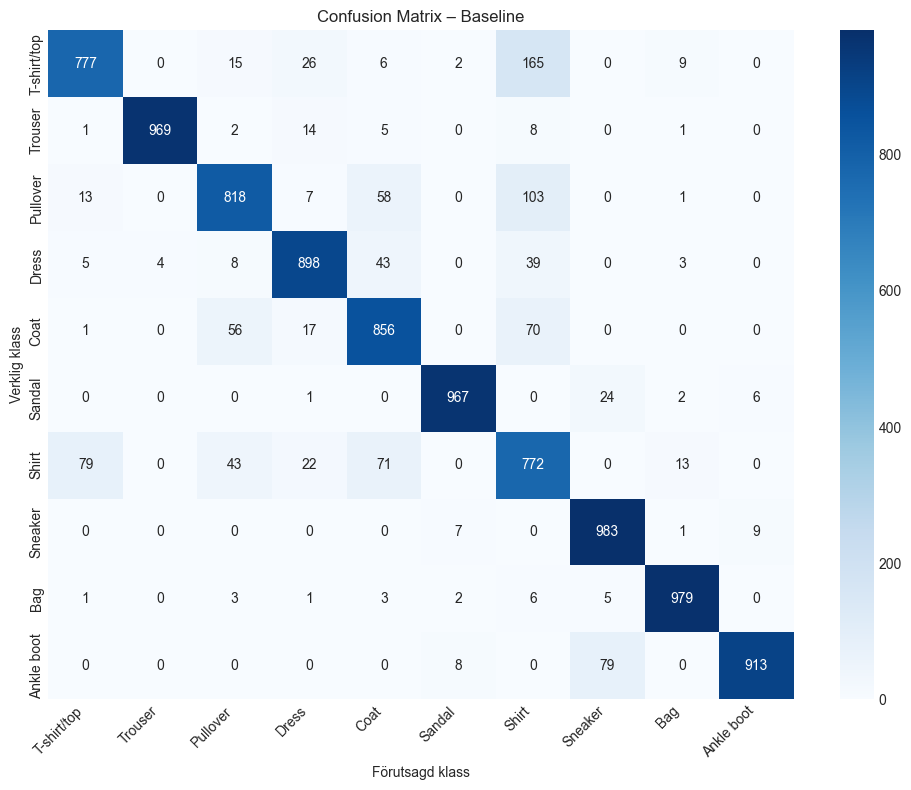


=== Classification Report – Baseline ===
              precision    recall  f1-score   support

 T-shirt/top       0.89      0.78      0.83      1000
     Trouser       1.00      0.97      0.98      1000
    Pullover       0.87      0.82      0.84      1000
       Dress       0.91      0.90      0.90      1000
        Coat       0.82      0.86      0.84      1000
      Sandal       0.98      0.97      0.97      1000
       Shirt       0.66      0.77      0.71      1000
     Sneaker       0.90      0.98      0.94      1000
         Bag       0.97      0.98      0.97      1000
  Ankle boot       0.98      0.91      0.95      1000

    accuracy                           0.89     10000
   macro avg       0.90      0.89      0.89     10000
weighted avg       0.90      0.89      0.89     10000



In [23]:
# Confusion Matrix – Baseline

y_pred = np.argmax(baseline_model.predict(x_test), axis=1)
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names, ax=ax)
ax.set_xlabel("Förutsagd klass")
ax.set_ylabel("Verklig klass")
ax.set_title("Confusion Matrix – Baseline")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("../images/confusion_matrix_baseline.png", dpi=150, bbox_inches="tight")
plt.show()

print("\n=== Classification Report – Baseline ===")
print(classification_report(y_test, y_pred, target_names=class_names))

**Baseline**

De svåraste klasserna är tydliga:
- **Shirt** klassificeras fel mest av alla — 772 rätt av 1000 (77.2%). Vanligaste
  felet är att Shirt förväxlas med T-shirt/top (79 fel), Coat (71 fel) och Pullover (43 fel).
- **T-shirt/top** förväxlas ofta med Shirt (165 fel).
- **Pullover** förväxlas med Coat (58 fel) och Shirt (103 fel).

Trouser, Bag, Sandal och Sneaker klassificeras nästan perfekt — de har tillräckligt
distinkta visuella egenskaper för att modellen inte ska förväxla dem.

### Confusion Matrix – Shift 10% (bästa augmentation-experiment)

Vi jämför nu baseline med det bästa augmentation-experimentet för att se om
augmentation förändrar vilka klasser som är svåra att klassificera.

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


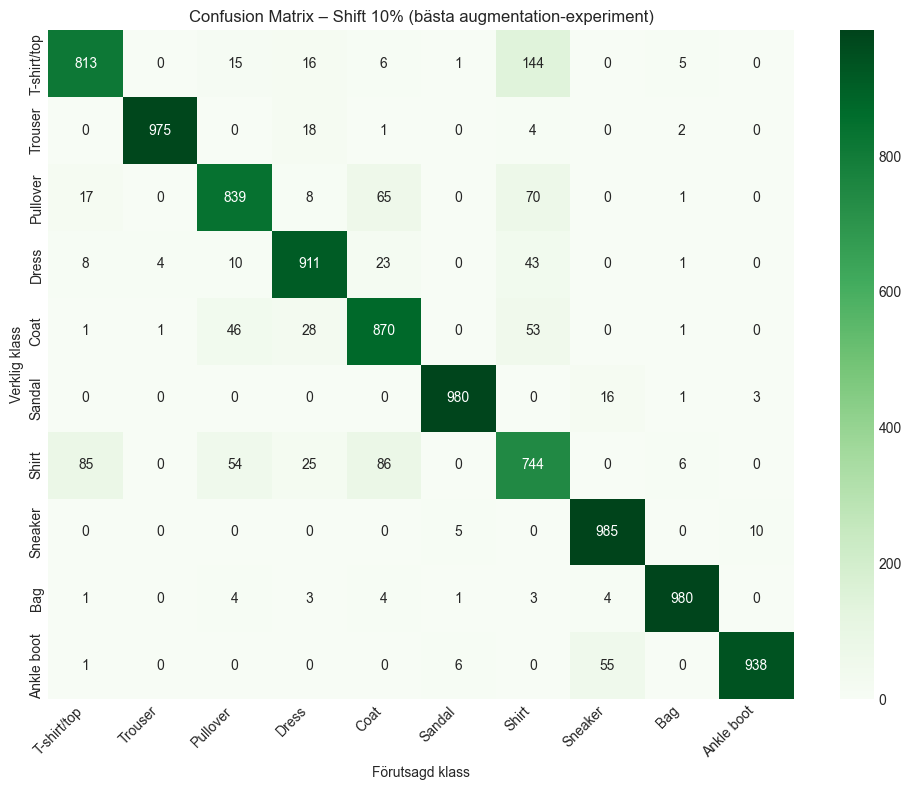


=== Classification Report – Shift 10% ===
              precision    recall  f1-score   support

 T-shirt/top       0.88      0.81      0.84      1000
     Trouser       0.99      0.97      0.98      1000
    Pullover       0.87      0.84      0.85      1000
       Dress       0.90      0.91      0.91      1000
        Coat       0.82      0.87      0.85      1000
      Sandal       0.99      0.98      0.98      1000
       Shirt       0.70      0.74      0.72      1000
     Sneaker       0.93      0.98      0.96      1000
         Bag       0.98      0.98      0.98      1000
  Ankle boot       0.99      0.94      0.96      1000

    accuracy                           0.90     10000
   macro avg       0.91      0.90      0.90     10000
weighted avg       0.91      0.90      0.90     10000



In [24]:
# Confusion Matrix – Shift 10% (bästa augmentation-experiment)

y_pred_best = np.argmax(shift_model.predict(x_test), axis=1)
cm_best = confusion_matrix(y_test, y_pred_best)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm_best, annot=True, fmt="d", cmap="Greens",
            xticklabels=class_names, yticklabels=class_names, ax=ax)
ax.set_xlabel("Förutsagd klass")
ax.set_ylabel("Verklig klass")
ax.set_title("Confusion Matrix – Shift 10% (bästa augmentation-experiment)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("../images/confusion_matrix_shift_10pct.png", dpi=150, bbox_inches="tight")
plt.show()

print("\n=== Classification Report – Shift 10% ===")
print(classification_report(y_test, y_pred_best, target_names=class_names))

**Shift 10% (bästa augmentation-experiment)**

Mönstret är likartat men med några förbättringar:
- **T-shirt/top** förbättras från 777 till 813 rätt — 36 fler korrekta.
- **Dress** förbättras från 898 till 911 rätt.
- **Coat** förbättras från 856 till 870 rätt.
- **Shirt** försämras något från 772 till 744 rätt.

De svåra klasserna — Shirt, T-shirt/top, Pullover och Coat — är fortfarande
svåra för båda modellerna. Förväxlingarna sker av samma anledning i båda fallen:
dessa plagg ser visuellt lika ut på 28x28 gråskalebilder, och shift-augmentation
kan inte lösa det underliggande problemet att klasserna är för lika varandra.

Classification report bekräftar bilden — Shirt har lägst f1-score i båda modellerna
(0.71 baseline, 0.72 shift), medan Trouser, Bag, Sandal och Sneaker
ligger på 0.96–0.98 i båda fallen.

### Slutsatser

#### Vad vi testade och varför

Vi tränade sex modeller med identisk CNN-arkitektur och jämförde dem systematiskt:
en baseline utan augmentation och fem experiment med olika typer av bildtransformationer
— rotation, zoom, shift samt mild och stark kombinerad augmentation.
Syftet var att undersöka om mer varierad träningsdata kan göra modellen mer robust
och minska overfitting.

---

#### Vad vi lärde oss

**1. Mild augmentation förbättrar generalisering utan att sänka accuracy.**
Shift 10% uppnådde den högsta test accuracy (90.35%) av alla experiment och hade
samtidigt det lägsta overfitting-gapet (-0.006). Rotation 5% och Zoom 10% låg
också över baseline i test accuracy med minimalt overfitting-gap.
Dessa tre experiment visar att rätt doserad augmentation ger en bättre modell
— inte bara på siffror, utan på hur modellen beter sig under träning.

**2. Baseline hade högst overfitting av alla experiment.**
Trots högst träningsnoggrannhet (96.2%) hade baseline det största gapet mot
validering (0.0595) och valideringsförlusten steg tydligt från epoch 6 och framåt.
Augmentation motverkade detta mönster effektivt i de mildare experimenten.

**3. Stark augmentation skadar modellen.**
Med rotation 15%, zoom 20% och shift 20% kombinerat sjönk test accuracy till
78.37% — nästan 12 procentenheter under baseline. Bilderna förändrades så kraftigt
att viktiga detaljer försvann och modellen inte längre kunde skilja klasser åt.
Det finns alltså en tydlig gräns där mer augmentation blir kontraproduktivt.

**4. Vissa klasser är svåra oavsett augmentation.**
Shirt, T-shirt/top, Pullover och Coat förväxlas konsekvent i alla experiment.
Det beror inte på dålig augmentation utan på att dessa plagg ser genuint lika ut
på 28x28 gråskalebilder — en begränsning i datasetet snarare än i modellen.

---

#### Begränsningar

- **Litet antal epoker** — vi tränade i 10 epoker. Augmentation-modeller behöver
  ofta fler epoker för att hinna lära in mönster från mer varierad data. Det är
  möjligt att Shift 10% och Rotation 5% hade presterat ännu bättre med 20–30 epoker.
- **Låg bildupplösning** — Fashion MNIST:s 28x28 pixlar sätter en naturlig gräns
  för hur mycket augmentation kan hjälpa. På bilder med högre upplösning och mer
  naturlig variation skulle effekten troligtvis vara tydligare.
- **Ingen kombination med regularisering** — vi testade augmentation isolerat.
  I praktiken kombineras det ofta med dropout eller batch normalization för ännu
  bättre generalisering.

---

#### Vad som hade varit intressant att utforska vidare

- **Fler epoker** för augmentation-modellerna för att se om gapet mot baseline minskar ytterligare.
- **Horisontell flip** — vi testade det inte eftersom vissa klädesplagg som skor
  kan se konstiga ut spegelvänt, men för symmetriska plagg som tröjor och väskor
  hade det kunnat hjälpa.
- **Augmentation kombinerat med dropout** — för att se om de två teknikerna
  förstärker varandra i att minska overfitting.
- **Samma experiment på ett mer komplext dataset** med högre upplösning, t.ex.
  CIFAR-10 eller en verklig klädesdataset, där augmentation troligtvis skulle
  visa en tydligare positiv effekt.